# 05. Teste: features filtradas por correlação no ml_ridge

In [1]:
import sys
sys.path.append("../src")
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge

import utils as ut

RANDOM_STATE = 42
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": "#444444", "axes.grid": True,
    "grid.color": "#e5e5e5", "grid.linewidth": 0.8, "font.size": 11,
})


In [2]:
train, test = ut.load_processed("../data/processed")
full = ut.make_full_series(train, test)
full_dates = full["Date"].values

origins = ut.walkforward_origins(len(train), len(test), max_h=max(ut.HORIZONS))
FEATURE_COLS = ut.feature_columns()

feat_train = ut.build_features(train)
feat_train = ut.build_direct_targets(feat_train, horizons=ut.HORIZONS)
target_cols = [f"target_h{h}" for h in ut.HORIZONS]
feat_train_clean = feat_train.dropna(subset=FEATURE_COLS + target_cols).reset_index(drop=True)
print(f"{len(FEATURE_COLS)} features originais, {len(feat_train_clean)} linhas de treino")


19 features originais, 1322 linhas de treino


## Seleção de features por correlação

As features são ordenadas pela correlação absoluta com `target_h1`, da mais forte para a mais fraca. Cada uma só entra no conjunto filtrado se sua correlação com todas as já selecionadas ficar abaixo de 0,9. Isso mantém a feature mais informativa de cada grupo redundante e descarta as que apenas repetem essa informação.

In [3]:
def select_features_by_correlation(df, feature_cols, target_col, threshold=0.9):
    corr_target = df[feature_cols].corrwith(df[target_col]).abs().sort_values(ascending=False)
    selected = []
    for feat in corr_target.index:
        if all(abs(df[feat].corr(df[s])) < threshold for s in selected):
            selected.append(feat)
    return selected

SELECTED_COLS = select_features_by_correlation(feat_train_clean, FEATURE_COLS, "target_h1", threshold=0.9)
print(f"{len(SELECTED_COLS)} de {len(FEATURE_COLS)} features mantidas:")
print(SELECTED_COLS)
print()
print("Descartadas por redundância:")
print([c for c in FEATURE_COLS if c not in SELECTED_COLS])


10 de 19 features mantidas:
['lag_1', 'roll_std_10', 'roll_std_5', 'roll_std_20', 'volume_lag1', 'return_5', 'return_1', 'month', 'day', 'dow']

Descartadas por redundância:
['lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_10', 'lag_20', 'roll_mean_5', 'roll_mean_10', 'roll_mean_20']


## Comparação na validação interna

Mesma divisão do notebook 03, os últimos 40 dias úteis do treino como validação interna, sem tocar no teste real. O Ridge (alpha=5.0) é treinado duas vezes para cada horizonte, uma com as 19 features originais e outra só com as features filtradas, e as métricas são comparadas lado a lado.

In [4]:
N_VAL = 40
inner_train = feat_train_clean.iloc[:-N_VAL]
inner_val = feat_train_clean.iloc[-N_VAL:]

rows_val = []
for h in ut.HORIZONS:
    ycol = f"target_h{h}"
    for label, cols in [("completo", FEATURE_COLS), ("filtrado", SELECTED_COLS)]:
        model = Ridge(alpha=5.0)
        model.fit(inner_train[cols], inner_train[ycol])
        pred = model.predict(inner_val[cols])
        m = ut.regression_metrics(inner_val[ycol], pred)
        rows_val.append({"horizon": h, "features": label, **m})

val_comparacao = pd.DataFrame(rows_val)
val_comparacao.pivot(index="features", columns="horizon", values="MAPE").round(2)


horizon,1,2,3
features,,,
completo,3.24,4.33,5.36
filtrado,3.20,4.30,5.34


## Comparação no walk-forward (mesmas 17 origens)

Para comparar com o restante do case na mesma base, os dois conjuntos de features são retreinados com todo o histórico disponível e avaliados nas mesmas 17 origens de validação walk-forward usadas em todos os outros notebooks.

In [5]:
def treinar_e_prever(cols, label):
    final_models = {}
    for h in ut.HORIZONS:
        ycol = f"target_h{h}"
        model = Ridge(alpha=5.0)
        model.fit(feat_train_clean[cols], feat_train_clean[ycol])
        final_models[h] = model

    rows = []
    for origin in origins:
        origin_date = full_dates[origin]
        history_raw = full.iloc[: origin + 1][["Date", "Close", "Volume"]]
        history_feat = ut.build_features(history_raw)
        x_row = history_feat.iloc[[-1]][cols]
        for h in ut.HORIZONS:
            pred = final_models[h].predict(x_row)[0]
            ut.append_predictions(rows, origin_date, full_dates, full["Close"].values, origin, h, label, pred)
    return pd.DataFrame(rows)

results_completo = treinar_e_prever(FEATURE_COLS, "ml_ridge_completo")
results_filtrado = treinar_e_prever(SELECTED_COLS, "ml_ridge_filtrado")

metrics_original = pd.read_csv("../results/metrics_ml.csv")
metrics_original = metrics_original[metrics_original["model"] == "ml_ridge"].copy()
metrics_original["model"] = "ml_ridge_completo"

metrics_filtrado = ut.summarize_by_horizon(results_filtrado)
metrics_filtrado["model"] = "ml_ridge_filtrado"

metrics_teste = pd.concat([metrics_original, metrics_filtrado], ignore_index=True)
metrics_teste.pivot(index="model", columns="horizon", values="MAPE").round(2)


horizon,1,2,3
model,,,
ml_ridge_completo,6.43,5.60,7.71
ml_ridge_filtrado,6.25,5.45,7.77


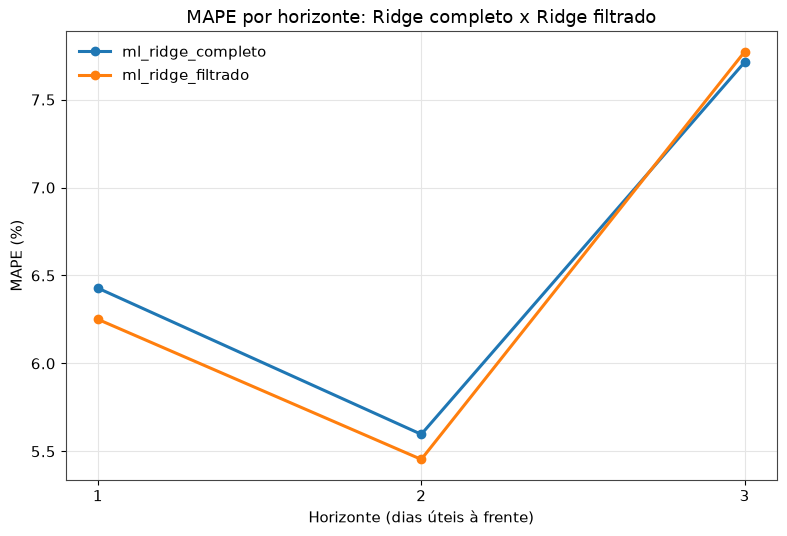

In [6]:
fig, ax = plt.subplots(figsize=(8, 5.5))
for model, g in metrics_teste.groupby("model"):
    g = g.sort_values("horizon")
    ax.plot(g["horizon"], g["MAPE"], marker="o", linewidth=2.2, label=model)
ax.set_xticks(ut.HORIZONS)
ax.set_xlabel("Horizonte (dias úteis à frente)")
ax.set_ylabel("MAPE (%)")
ax.set_title("MAPE por horizonte: Ridge completo x Ridge filtrado")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


## Resultado

A tabela e o gráfico acima trazem os números de MAPE por horizonte para o Ridge com as 19 features originais e para o Ridge com as features filtradas por correlação, lado a lado nas mesmas 17 origens.